In [1]:
#N1: imports + dataset path




import os
N_THREADS = 16                                   # 64 cores / 4 notebooks
os.environ["OMP_NUM_THREADS"] = str(N_THREADS)   # must be set BEFORE importing torch/numpy
os.environ["MKL_NUM_THREADS"] = str(N_THREADS)

import pickle
import numpy as np
import torch
torch.set_num_threads(N_THREADS)                 # PyTorch uses only these cores
print("threads:", torch.get_num_threads())

# os.sched_setaffinity(0, range(0, 16))    # file 1
# os.sched_setaffinity(0, range(16, 32)) # file 2
# os.sched_setaffinity(0, range(32, 48)) # file 3
os.sched_setaffinity(0, range(48, 64)) # file 4


import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
import time
import matplotlib.pyplot as plt

BASE = '/home/worker/Downloads/talha/week6/fruit notebooks/fruits-360/'   # folder that holds Training/ and Test/

TRAIN_DIR = os.path.join(BASE, 'Training')
TEST_DIR  = os.path.join(BASE, 'Test')
all_classes = sorted(os.listdir(TRAIN_DIR))

print(f"{len(all_classes)} classes")


threads: 16
268 classes


In [2]:
#N2: 20 problems x 5 classes (names match the folder names exactly)
# Each group holds classes that look alike, like the CIFAR-100 superclasses did.

SCRIPT_NAMES = ["P1_apples", "P2_citrus", "P3_berries", "P4_tropical", "P5_vegetables",
                "P6_stone_pear", "P7_apples_2", "P8_apples_3", "P9_cherries", "P10_grapes",
                "P11_citrus_2", "P12_pears", "P13_flat_stone", "P14_berries_2", "P15_passion",
                "P16_tropical_2", "P17_small_exotic", "P18_roots", "P19_peppers", "P20_tomatoes"]

GROUP_FOLDERS = [
    ["Apple Braeburn 1", "Apple Golden 1", "Apple Granny Smith 1", "Apple Pink Lady 1", "Apple Red Delicious 1"],  # P1
    ["Clementine 1", "Grapefruit Pink 1", "Lemon 1", "Limes 1", "Orange 1"],                                    # P2
    ["Blueberry 1", "Cherry 1", "Raspberry 1", "Redcurrant 1", "Strawberry 1"],                                 # P3
    ["Banana 1", "Kiwi 1", "Mango 1", "Papaya 1", "Pineapple 1"],                                               # P4
    ["Eggplant 1", "Onion White 1", "Pepper Red 1", "Potato Red 1", "Tomato 1"],                                # P5
    ["Apricot 1", "Nectarine 1", "Peach 1", "Pear 1", "Plum 1"],                                                # P6
    ["Apple Red 1", "Apple Red 2", "Apple Golden 2", "Apple Golden 3", "Apple Red Yellow 1"],                   # P7
    ["Apple Crimson Snow 1", "Apple 5", "Apple 6", "Apple 12", "Apple 21"],                                     # P8
    ["Cherry Sour 1", "Cherry Wax Black 1", "Cherry Wax Red 1", "Cherry Wax Red 2", "Cherry Wax Yellow 1"],     # P9
    ["Grape 1", "Grape Pink 1", "Grape White 1", "Grape White 2", "Grape White 3"],                             # P10
    ["Grapefruit White 1", "Lemon Meyer 1", "Mandarine 1", "Tangelo 1", "Kumquats 1"],                          # P11
    ["Pear Abate 1", "Pear Monster 1", "Pear Williams 1", "Pear 12", "Quince 1"],                               # P12
    ["Nectarine Flat 1", "Nectarine Flat 2", "Peach Flat 1", "Plum 2", "Kaki 1"],                               # P13
    ["Blackberry 1", "Mulberry 1", "Huckleberry 1", "Gooseberry 1", "Raspberry 4"],                             # P14
    ["Granadilla 1", "Maracuja 1", "Passion Fruit 1", "Pitahaya Red 1", "Rambutan 1"],                          # P15
    ["Banana Red 1", "Banana Lady Finger 1", "Mango Red 1", "Carambola 1", "Guava 1"],                          # P16
    ["Lychee 1", "Salak 1", "Physalis 1", "Physalis with Husk 1", "Pepino 1"],                                  # P17
    ["Potato White 1", "Potato Sweet 1", "Potato Red 2", "Beetroot 1", "Kohlrabi 1"],                           # P18
    ["Pepper 2", "Pepper Green 1", "Pepper Red 3", "Pepper Red 4", "Pepper Yellow 1"],                          # P19
    ["Tomato 4", "Tomato 11", "Tomato Cherry Red 1", "Tomato Yellow 1", "Tomato Maroon 2"],                     # P20
]

missing = [f for grp in GROUP_FOLDERS for f in grp if f not in all_classes]
assert not missing, f"these folders don't exist: {missing}"
flat = [f for grp in GROUP_FOLDERS for f in grp]
assert len(set(flat)) == len(flat), "the same class is used in two groups"

for name, grp in zip(SCRIPT_NAMES, GROUP_FOLDERS):
    print(f"{name:14s} {grp}")
print("\n20 problems, 5 classes each, 100 classes used")


P1_apples      ['Apple Braeburn 1', 'Apple Golden 1', 'Apple Granny Smith 1', 'Apple Pink Lady 1', 'Apple Red Delicious 1']
P2_citrus      ['Clementine 1', 'Grapefruit Pink 1', 'Lemon 1', 'Limes 1', 'Orange 1']
P3_berries     ['Blueberry 1', 'Cherry 1', 'Raspberry 1', 'Redcurrant 1', 'Strawberry 1']
P4_tropical    ['Banana 1', 'Kiwi 1', 'Mango 1', 'Papaya 1', 'Pineapple 1']
P5_vegetables  ['Eggplant 1', 'Onion White 1', 'Pepper Red 1', 'Potato Red 1', 'Tomato 1']
P6_stone_pear  ['Apricot 1', 'Nectarine 1', 'Peach 1', 'Pear 1', 'Plum 1']
P7_apples_2    ['Apple Red 1', 'Apple Red 2', 'Apple Golden 2', 'Apple Golden 3', 'Apple Red Yellow 1']
P8_apples_3    ['Apple Crimson Snow 1', 'Apple 5', 'Apple 6', 'Apple 12', 'Apple 21']
P9_cherries    ['Cherry Sour 1', 'Cherry Wax Black 1', 'Cherry Wax Red 1', 'Cherry Wax Red 2', 'Cherry Wax Yellow 1']
P10_grapes     ['Grape 1', 'Grape Pink 1', 'Grape White 1', 'Grape White 2', 'Grape White 3']
P11_citrus_2   ['Grapefruit White 1', 'Lemon Meyer 1', 

P1_apples      train  2410  test  806  train per class [492, 480, 492, 456, 490]
P2_citrus      train  2441  test  822  train per class [490, 490, 492, 490, 479]
P3_berries     train  2428  test  812  train per class [462, 492, 490, 492, 492]
P4_tropical    train  2428  test  818  train per class [490, 466, 490, 492, 490]
P5_vegetables  train  2760  test  920  train per class [468, 438, 666, 450, 738]
P6_stone_pear  train  2415  test  807  train per class [492, 492, 492, 492, 447]
P7_apples_2    train  2449  test  817  train per class [492, 492, 492, 481, 492]
P8_apples_3    train  2311  test  767  train per class [444, 440, 473, 466, 488]
P9_cherries    train  2384  test  792  train per class [456, 492, 492, 452, 492]
P10_grapes     train  2433  test  815  train per class [469, 492, 490, 490, 492]
P11_citrus_2   train  2452  test  828  train per class [492, 490, 490, 490, 490]
P12_pears      train  2429  test  820  train per class [490, 490, 490, 469, 490]
P13_flat_stone train  2345  

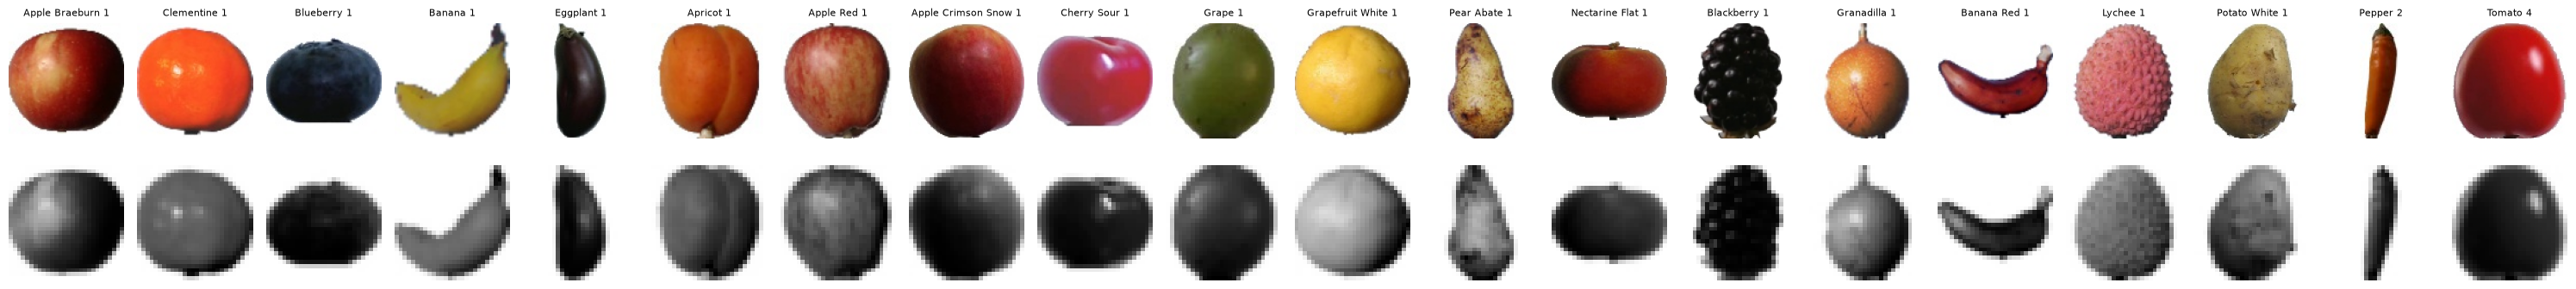

In [3]:
#N3: load images and convert to 28x28 grayscale (784 values per image, same format as EMNIST)
# Fruits-360 images are 100x100 colour photos on a white background, already upright.

def load_class(split_dir, folder):
    paths = sorted(glob.glob(os.path.join(split_dir, folder, '*')))
    arr = np.empty((len(paths), 784), dtype=np.uint8)
    for i, p in enumerate(paths):
        img = Image.open(p).convert('L').resize((28, 28), Image.BILINEAR)   # grayscale, 100x100 -> 28x28
        arr[i] = np.asarray(img, dtype=np.uint8).reshape(-1)
    return arr

t0 = time.time()
group_data = []      # per group: (x_train, y_train, x_test, y_test), labels 0-4 = position in the group list
for m, folders in enumerate(GROUP_FOLDERS):
    xs_tr, ys_tr, xs_te, ys_te = [], [], [], []
    for label, folder in enumerate(folders):
        a_tr = load_class(TRAIN_DIR, folder)
        a_te = load_class(TEST_DIR, folder)
        xs_tr.append(a_tr); ys_tr.append(np.full(len(a_tr), label, dtype=np.int64))
        xs_te.append(a_te); ys_te.append(np.full(len(a_te), label, dtype=np.int64))
    group_data.append((np.concatenate(xs_tr), np.concatenate(ys_tr),
                       np.concatenate(xs_te), np.concatenate(ys_te)))
    per_class = [len(x) for x in xs_tr]
    print(f"{SCRIPT_NAMES[m]:14s} train {len(group_data[m][0]):5d}  test {len(group_data[m][2]):4d}  "
          f"train per class {per_class}")
print(f"loaded in {time.time()-t0:.0f}s")

# visual check: one image per group, top = original colour, bottom = 28x28 grayscale
fig, axes = plt.subplots(2, 20, figsize=(30, 3.8))
for m, folders in enumerate(GROUP_FOLDERS):
    p = sorted(glob.glob(os.path.join(TRAIN_DIR, folders[0], '*')))[0]
    axes[0, m].imshow(Image.open(p).convert('RGB')); axes[0, m].set_title(folders[0], fontsize=8)
    axes[1, m].imshow(group_data[m][0][0].reshape(28, 28), cmap='gray')
    axes[0, m].axis('off'); axes[1, m].axis('off')
plt.tight_layout(); plt.show()


In [4]:
#N4: building 20 datasets (standardized with each group's own training mean and std)

train_datasets = []
test_datasets  = []

for m in range(20):
    x_tr, y_tr, x_te, y_te = group_data[m]
    x_tr = torch.tensor(x_tr, dtype=torch.float32)
    x_te = torch.tensor(x_te, dtype=torch.float32)
    y_tr = torch.tensor(y_tr, dtype=torch.long)
    y_te = torch.tensor(y_te, dtype=torch.long)

    mean = x_tr.mean()
    std  = x_tr.std()
    x_tr = (x_tr - mean) / std
    x_te = (x_te - mean) / std

    train_datasets.append(TensorDataset(x_tr, y_tr))
    test_datasets.append(TensorDataset(x_te, y_te))

    print(f"{SCRIPT_NAMES[m]:14s} train {len(x_tr):5d}  test {len(x_te):4d}  "
          f"mean {x_tr.mean():.2f}  std {x_tr.std():.2f}")


P1_apples      train  2410  test  806  mean -0.00  std 1.00
P2_citrus      train  2441  test  822  mean -0.00  std 1.00
P3_berries     train  2428  test  812  mean 0.00  std 1.00
P4_tropical    train  2428  test  818  mean 0.00  std 1.00
P5_vegetables  train  2760  test  920  mean -0.00  std 1.00
P6_stone_pear  train  2415  test  807  mean -0.00  std 1.00
P7_apples_2    train  2449  test  817  mean -0.00  std 1.00
P8_apples_3    train  2311  test  767  mean 0.00  std 1.00
P9_cherries    train  2384  test  792  mean 0.00  std 1.00
P10_grapes     train  2433  test  815  mean -0.00  std 1.00
P11_citrus_2   train  2452  test  828  mean 0.00  std 1.00
P12_pears      train  2429  test  820  mean 0.00  std 1.00
P13_flat_stone train  2345  test  785  mean 0.00  std 1.00
P14_berries_2  train  2351  test  784  mean -0.00  std 1.00
P15_passion    train  2452  test  828  mean -0.00  std 1.00
P16_tropical_2 train  2346  test  792  mean 0.00  std 1.00
P17_small_exotic train  2454  test  822  mean 0.

In [5]:
#N5: DataLoaders + settings

BATCH_SIZE = 32
train_loaders = [DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True) for ds in train_datasets]
test_loaders  = [DataLoader(ds, batch_size=256, shuffle=False)       for ds in test_datasets]

def infinite(loader):
    """Endless batches with a NEW shuffle on every pass (itertools.cycle would replay the first pass forever)."""
    while True:
        for batch in loader:
            yield batch

DEVICE          = 'cpu' if torch.cuda.is_available() else 'cpu'
INPUT_SIZE      = 784           # 28*28*1 grayscale
HIDDEN_SIZE     = 128
NUM_G_SETS      = 6
NUM_PROBLEMS    = 20
CLASSES_PER     = 5
TOTAL_CLASSES   = NUM_PROBLEMS * CLASSES_PER   # 100

LEARNING_RATE   = 0.001
MOMENTUM        = 0.9
NUM_EPOCHS      = 20
STEPS_PER_EPOCH = min(len(ds) for ds in train_datasets) // BATCH_SIZE   # one full pass of the smallest group
N_RUNS          = 30
EVAL_EVERY      = 5
PRINT_EVERY     = 5
print(f"Device: {DEVICE}")
print(f"Runs: {N_RUNS}  Epochs: {NUM_EPOCHS}  Steps/epoch: {STEPS_PER_EPOCH}")
print(f"Both train loss and test loss = avg CE per problem  (5-way random guess = ln5 = {np.log(5):.3f})")


Device: cpu
Runs: 30  Epochs: 20  Steps/epoch: 71
Both train loss and test loss = avg CE per problem  (5-way random guess = ln5 = 1.609)


In [6]:
#N9: MODEL: WIDE NETWORK
# One ordinary network shared by all 20 problems: one hidden layer + 5 shared outputs (no switching).
# WIDE = 768 -> 784*768 + 768*5 = 605,952 parameters (exactly the same as the compound network)

WIDE         = 768
accs_wide    = []
trloss_wide  = []
teloss_wide  = []
tracc_wide   = []   # train accuracy per run

print(f"Training WIDE {WIDE}-neuron network on Fruits-360 (20 groups x 5 classes)...")
print(f"Params: 784*{WIDE} + {WIDE}*{CLASSES_PER} = {784*WIDE + WIDE*CLASSES_PER:,}")
print(f"{'Run':>4} {'Ep':>4} | {'Tr loss':>8} {'Te loss':>8} | {'Tr acc':>7} {'Te acc':>7} | "
      + " ".join(f"{'P'+str(i+1):>5}" for i in range(20)))
print("-" * 175)
t0 = time.time()

for run in range(N_RUNS):

    W_wide    = nn.Parameter(torch.empty(WIDE, INPUT_SIZE, device=DEVICE))      # [768, 784]
    Wout_wide = nn.Parameter(torch.empty(CLASSES_PER, WIDE, device=DEVICE))     # [5, 768]
    nn.init.kaiming_normal_(W_wide.data,    mode="fan_in", nonlinearity="relu")
    nn.init.kaiming_normal_(Wout_wide.data, mode="fan_in", nonlinearity="relu")

    optimizer_wide = torch.optim.SGD([W_wide, Wout_wide], lr=LEARNING_RATE, momentum=MOMENTUM)
    inf_iters_wide = [infinite(loader) for loader in train_loaders]   # reshuffles every pass
    last_tr_loss   = 0.0

    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0.0
        tr_correct = tr_total = 0
        for step in range(STEPS_PER_EPOCH):
            optimizer_wide.zero_grad()
            total_loss = torch.zeros((), device=DEVICE)
            for m in range(20):
                x, y = next(inf_iters_wide[m])
                x, y = x.to(DEVICE), y.to(DEVICE)
                h    = F.relu(x @ W_wide.T)
                out  = h @ Wout_wide.T            # [batch, 5], same 5 outputs for every problem
                total_loss = total_loss + F.cross_entropy(out, y)
                tr_correct += (out.argmax(1) == y).sum().item()
                tr_total   += y.size(0)
            total_loss.backward()
            optimizer_wide.step()
            epoch_loss += total_loss.item()

        avg_tr       = epoch_loss / STEPS_PER_EPOCH / NUM_PROBLEMS
        last_tr_loss = avg_tr
        tr_acc       = tr_correct / tr_total * 100

        if (epoch + 1) % EVAL_EVERY == 0:
            ep_accs    = []
            ep_te_loss = 0.0
            with torch.no_grad():
                for m in range(20):
                    correct = total = 0
                    m_loss  = n_bat = 0.0
                    for x, y in test_loaders[m]:
                        x, y    = x.to(DEVICE), y.to(DEVICE)
                        out     = F.relu(x @ W_wide.T) @ Wout_wide.T
                        correct += (out.argmax(1) == y).sum().item()
                        total   += y.size(0)
                        m_loss  += F.cross_entropy(out, y).item()
                        n_bat   += 1
                    ep_accs.append(correct / total * 100)
                    ep_te_loss += m_loss / n_bat
            avg_te = ep_te_loss / NUM_PROBLEMS

            if (run + 1) % PRINT_EVERY == 0:
                acc_str = " ".join(f"{acc:5.1f}" for acc in ep_accs)
                print(f"{run+1:4d} {epoch+1:4d} | {avg_tr:8.4f} {avg_te:8.4f} | "
                      f"{tr_acc:6.2f}% {np.mean(ep_accs):6.2f}% | {acc_str}")

    run_accs    = []
    run_te_loss = 0.0
    with torch.no_grad():
        for m in range(20):
            correct = total = 0
            m_loss  = n_bat = 0.0
            for x, y in test_loaders[m]:
                x, y    = x.to(DEVICE), y.to(DEVICE)
                out     = F.relu(x @ W_wide.T) @ Wout_wide.T
                correct += (out.argmax(1) == y).sum().item()
                total   += y.size(0)
                m_loss  += F.cross_entropy(out, y).item()
                n_bat   += 1
            run_accs.append(correct / total * 100)
            run_te_loss += m_loss / n_bat

    accs_wide.append(run_accs)
    trloss_wide.append(last_tr_loss)
    tracc_wide.append(tr_acc)
    teloss_wide.append(run_te_loss / NUM_PROBLEMS)

    if (run + 1) % PRINT_EVERY == 0:
        print(f"  \u2192 run {run+1}  train acc {tr_acc:.2f}%  test acc {np.mean(run_accs):.2f}%  "
              f"tr loss {last_tr_loss:.4f}  te loss {run_te_loss/NUM_PROBLEMS:.4f}  [{time.time()-t0:.0f}s]\n")

print(f"\nWIDE {WIDE} DONE:  "
      f"train acc {np.mean(tracc_wide):.2f}% \u00B1 {np.std(tracc_wide):.2f}%  |  "
      f"test acc {np.mean([np.mean(r) for r in accs_wide]):.2f}% \u00B1 "
      f"{np.std([np.mean(r) for r in accs_wide]):.2f}%  |  "
      f"train loss {np.mean(trloss_wide):.4f}  test loss {np.mean(teloss_wide):.4f}\n")
print("per-problem test acc (mean of all 30 runs):", np.round(np.mean(accs_wide, axis=0), 1))


Training WIDE 768-neuron network on Fruits-360 (20 groups x 5 classes)...
Params: 784*768 + 768*5 = 605,952
 Run   Ep |  Tr loss  Te loss |  Tr acc  Te acc |    P1    P2    P3    P4    P5    P6    P7    P8    P9   P10   P11   P12   P13   P14   P15   P16   P17   P18   P19   P20
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   5    5 |   0.2562   0.6770 |  94.22%  77.50% |  68.6  81.9  79.4  76.3  56.2  64.9  70.6  87.2  97.9  94.4  76.4  76.6  73.0  87.5  82.2  62.5  82.6  57.8  85.5  88.4
   5   10 |   0.0807   0.6309 |  99.08%  83.18% |  76.9  89.5  81.0  87.8  62.2  70.5  78.3  95.0  98.4  96.2  89.5  82.1  80.0  92.2  81.5  71.8  86.5  59.1  93.1  91.8
   5   15 |   0.0378   0.5629 |  99.80%  85.21% |  79.0  90.6  80.7  88.4  73.6  72.2  77.2  95.2  98.1  97.8  92.6  82.1  81.9  95.2  89.6  73.7  85.6  60.7  95.1  94.8
   5   20 |   0.0230   0.5754 |  99.